In [10]:
import torch
import numpy as np
import s3fs
import zarr
import tqdm

from diffusers import UNet2DModel
from diffusers import DDPMScheduler

import torch.optim as optim
import torch.nn as nn

model = UNet2DModel(
    sample_size=64,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)


noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

def train_step(model, noise_scheduler, clean_image, optimizer, loss):
    batch_size = clean_image.shape[0]
    optimizer.zero_grad()
    noise = torch.randn_like(clean_image)
    t = torch.randint(0, noise_scheduler.config.num_train_timesteps, (batch_size,))
    image_t = noise_scheduler.add_noise(clean_image, noise, t)
    noise_pred = model(image_t, t, return_dict=False)[0]
    l = loss(noise_pred, noise)
    l.backward()
    optimizer.step()
    return l.item()


def diffuse(model, noise_scheduler, prediction_shape):
    sample = torch.randn(prediction_shape)
    noise_scheduler.set_timesteps(noise_scheduler.config.num_train_timesteps)
    with torch.no_grad():
        for t in tqdm.tqdm(noise_scheduler.timesteps):
            noise_pred = model(sample, t, return_dict=False)[0]
            sample = noise_scheduler.step(noise_pred, t, sample, return_dict=False)[0]
    return sample


class S3FlowDataset(torch.utils.data.Dataset):
    def __init__(self, y_index):
        self.y_index = y_index
        self._fs = None
        self._s3_map = None

    def _ensure_connection(self):
        if self._fs is None:
            file_path = "simulations/flow_export/A1/data.zarr"
            self._fs = s3fs.S3FileSystem(profile='default', client_kwargs={
                'endpoint_url': 'http://localhost:9000',
            })
            s3_map = s3fs.S3Map(root=file_path, s3=self._fs, check=False)
            self._s3_map = zarr.open(store=s3_map, mode="r").astype(np.float32)[:100, :3, ::2, :, ::2]

    @property
    def z(self):
        self._ensure_connection()
        return self._s3_map

    def __len__(self):
        return self.z.shape[0]
    def __getitem__(self, i):
        return self.z[i, :, :, self.y_index, :]




In [2]:
dataset = S3FlowDataset(0)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=16, shuffle=True,
    num_workers=0, pin_memory=True,
)

In [3]:
dataset.z.shape

(100, 3, 64, 129, 64)

In [4]:

loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch in tqdm.tqdm(dataloader):
        epoch_loss += train_step(model, noise_scheduler, batch, optimizer, loss_fn)

    print(f"Epoch {epoch + 1}/{num_epochs} - Avg Loss* {epoch_loss / len(dataloader):.4f}")


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:09<00:00,  1.32s/it]


Epoch 1/20 - Avg Loss* 0.7103


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:09<00:00,  1.41s/it]


Epoch 2/20 - Avg Loss* 0.4922


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:08<00:00,  1.19s/it]


...

Epoch 18/20 - Avg Loss* 0.0982


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:07<00:00,  1.14s/it]


Epoch 19/20 - Avg Loss* 0.0930


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:07<00:00,  1.11s/it]

Epoch 20/20 - Avg Loss* 0.0933


In [5]:
torch.save(model.state_dict(), 'model.pt')

In [6]:
model.load_state_dict(torch.load('model.pt'))

<All keys matched successfully>

In [11]:
sample = diffuse(model, noise_scheduler, (1, 3, 64, 64))

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [08:23<00:00,  1.99it/s]


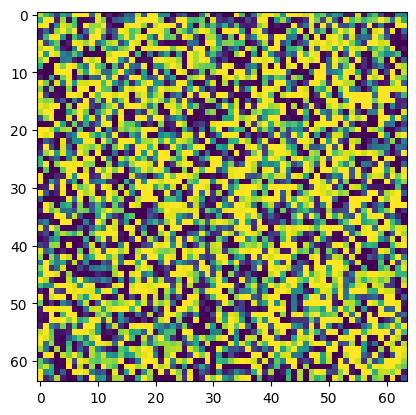

In [31]:
import matplotlib.pyplot as plt
plt.imshow(sample[0, 0])
plt.show()

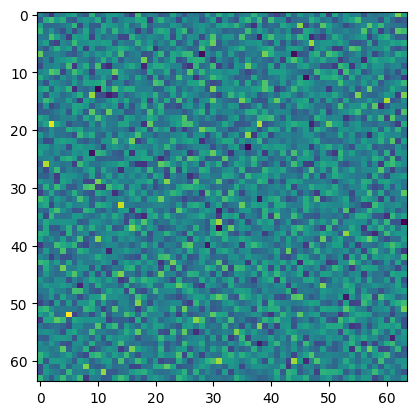

In [35]:
plt.imshow(dataset[0][2])
plt.show()